In [1]:
!pip install lightning
!pip install catboost
!pip install xgboost
!pip install torch
!pip -q install gdown

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


 # Импорт библиотек



Установим фиксированное начальное значение ("seed") для генераторов случайных чисел, чтобы обеспечить воспроизводимость экспериментов.
Импортируем необходимые библиотеки

In [2]:
#Импорт необходимых библиотек
import random
import numpy as np
import pandas as pd
import lightning as L
import timm
import torch
import torch.nn as nn
import torchmetrics
from torch.utils.data import DataLoader, Dataset, TensorDataset, WeightedRandomSampler
from torchsummary import summary
from torchvision import datasets, models
from torchvision.models import resnet18
from torchvision.transforms import v2
from collections import Counter
import matplotlib.pyplot as plt
import requests
import gdown
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split


In [3]:
import lightgbm
import seaborn as sns
import sklearn.datasets

from sklearn.svm import SVC
from sklearn.metrics import matthews_corrcoef, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import (
    PrecisionRecallDisplay,
    accuracy_score,
    classification_report,
    precision_recall_curve,
)
from sklearn.svm import SVC, LinearSVC
import xgboost
import catboost
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance as plot_importance_xgb
from lightgbm import plot_importance
import torch.optim as optim
import pytorch_lightning as pl
from torchmetrics import F1Score, MetricCollection
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassAUROC,
    MulticlassF1Score,
    MultilabelAccuracy,
    MultilabelF1Score,
)
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping,ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger

# Установка seed

In [4]:
def set_seed():
    random.seed(42)
    np.random.seed(42)

set_seed()
L.seed_everything(42)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


42

# Импорт датасета


Импортируем датасет для смоделированных спектров (тренировочный датасет) и для экспериментальных (тестовый датасет).
Запустив этот код вы сможете скачать датасет в виде таблицы csv формата, содержащей:
1)Признаки: Колонки 0-2246 содержат числовые данные, представляющие собой значения интенсивности сигналов ЭПР. Колонки 2247-2249 содержат числовые данные, а именно-  количество пиков в спектре , минимальное и максимальное значения магнитного поля, в диапазоне между которыми наблюдаются сигналы ЭПР
2)Метки для 11 классов радикалов. Каждая метка- это название радикала присутствующего в спектре.  hfc в конце названия метки обозначает наличие сверхтонкого взаимодействия для данного радикала


In [5]:
#смоделированные спектры (тренировочный датасет)
file_id = '1-SC_dpf5pkbEN9OOIGG2bG39-9PZ0DMr'
url = f'https://drive.google.com/uc?id={file_id}&export=download'
output = 'dataset_EPR_spectra.csv'

response = requests.get(url, allow_redirects=True)
with open(output, 'wb') as f:
    f.write(response.content)


In [6]:
#экспериментальные спектры (тестовый датасет)
file_id = '1Jx0CSXGNXCpYLRK0kAmRI4nRU56-daSF'
url = f'https://drive.google.com/uc?id={file_id}&export=download'
output = 'dataset_EPR_spectra_EXP.csv'

response = requests.get(url, allow_redirects=True)
with open(output, 'wb') as f:
    f.write(response.content)

Выведем первые 5 строк тренировочного, а затем тестового датасетов

In [7]:
df = pd.read_csv("dataset_EPR_spectra.csv")
df = shuffle(df, random_state=42).reset_index(drop=True)
df.head()


,intensity_0,intensity_1,intensity_2,intensity_3,intensity_4,intensity_5,intensity_6,intensity_7,intensity_8,intensity_9,...,intensity_449,intensity_450,intensity_451,intensity_452,intensity_453,intensity_454,num_peaks,max_peak_field,min_peak_field,label_idx
0,0.010697,-0.002510,-0.002269,0.007265,0.004388,0.002967,-0.005868,0.000588,0.006388,0.006010,...,0.002136,0.005939,0.000767,0.002273,-0.000630,0.008653,4.0,347.015144,340.859795,1
1,0.004002,0.001482,0.003252,0.010491,0.001696,0.004110,-0.004773,0.008047,0.010233,-0.007528,...,0.004215,0.007606,-0.008194,-0.004026,0.005633,-0.004546,2.0,355.544700,350.796287,5
2,-0.017725,0.001481,0.005259,-0.005027,-0.007025,-0.001027,0.011042,0.008259,0.002500,-0.014433,...,-0.005358,0.000877,0.005428,0.000128,-0.000790,-0.005887,2.0,351.060088,348.158280,5
3,0.006752,0.015706,0.020092,0.009815,0.009087,0.011095,0.019041,0.007039,0.015112,0.019481,...,-0.005851,0.001542,0.011110,-0.000827,0.003475,0.007159,3.0,344.816805,337.430386,2
4,-0.004280,-0.002077,-0.009336,-0.013942,-0.006158,-0.008812,-0.010440,-0.005180,-0.008615,0.003376,...,0.010034,-0.008294,-0.001156,0.006026,0.000100,-0.003045,2.0,344.465071,343.673669,0


In [8]:
df_test = pd.read_csv("dataset_EPR_spectra_EXP.csv")
df_test = shuffle(df_test, random_state=42).reset_index(drop=True)
df_test.head()

,intensity_0,intensity_1,intensity_2,intensity_3,intensity_4,intensity_5,intensity_6,intensity_7,intensity_8,intensity_9,...,intensity_449,intensity_450,intensity_451,intensity_452,intensity_453,intensity_454,num_peaks,max_peak_field,min_peak_field,label_idx
0,-0.011567,-0.014407,-0.006336,0.001442,-0.000623,0.007788,0.016369,-0.000034,-0.007421,0.001668,...,-0.001864,-0.027427,-0.002673,0.004196,-0.002219,-0.000251,4.0,347.103078,340.683928,1
1,-0.004439,0.004848,0.010371,0.006063,-0.001003,-0.011373,0.022317,-0.007826,-0.010164,-0.009896,...,0.009788,-0.009615,-0.034075,-0.009426,-0.006418,-0.010561,2.0,350.004885,346.311676,5
2,-0.011603,-0.006887,0.002935,-0.012197,-0.004921,-0.010516,-0.013064,-0.023097,-0.015035,-0.029047,...,-0.003828,0.002857,0.026979,0.001640,-0.011225,-0.000743,2.0,357.127504,352.115291,5
3,0.026932,-0.003513,-0.039813,-0.035129,0.001171,-0.011710,-0.085480,-0.007026,-0.005855,-0.079625,...,-0.100703,-0.108899,-0.067916,-0.060890,-0.028103,-0.127635,2.0,344.904739,344.113337,3
4,-0.002670,0.011251,-0.004386,0.000953,-0.004195,-0.008200,0.001716,-0.012395,-0.000763,-0.007818,...,-0.086957,-0.094012,-0.086194,-0.077231,-0.095919,-0.082380,2.0,344.816805,343.849536,3


Выделим признаки и метки в тренировочном и тестовом датасетах.

In [9]:
x = df.iloc[:, :-1]   # Признаки
y = df["label_idx"].values # Метки
x_test = df_test.iloc[:, :-1]   # Признаки
y_test = df_test["label_idx"].values # Метки

Разделим тренировочный датасет в соотношении 9:1 на train и validation

In [10]:
x_train, x_val, y_train, y_val,  = train_test_split(
    x, y, test_size=0.1, stratify=y, random_state=42
)

'\nx_val, x_test, y_val, y_test = train_test_split(\n    x_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42\n)\n'

Выведем все классы радикалов и количество обьектов в датасете для каждого класса

In [11]:
#Таблица соответствия классов
class_map = pd.DataFrame({
    "label_idx": [0, 1, 2, 3, 4, 5, 6],
    "class_name": [
        "С_rad_noisy_normalized",
        "N_rad_noisy_normalized",
        "O_radical_noisy_normalized",
        "O_vac_noisy_normalized",
        "O2_minus_noisy_normalized",
        "Ti3+_surface_noisy_normalized",
        "Ti3+_bulk_noisy_normalized"
    ]
})

#Подсчёт количества объектов
train_counts = (
    df["label_idx"]
    .value_counts()
    .rename_axis("label_idx")
    .reset_index(name="train_count")
)

test_counts = (
    df_test["label_idx"]
    .value_counts()
    .rename_axis("label_idx")
    .reset_index(name="test_count")
)

summary = (
    class_map
    .merge(train_counts, on="label_idx", how="left")
    .merge(test_counts, on="label_idx", how="left")
    .fillna(0)
)
summary["train_count"] = summary["train_count"].astype(int)
summary["test_count"] = summary["test_count"].astype(int)

summary = summary.rename(columns={
    "label_idx": "метка класса",
    "class_name": "название радикала",
    "train_count": "количество объектов (train)",
    "test_count": "количество объектов (test)"
})

summary


,метка класса,название радикала,количество объектов (train),количество объектов (test)
0,0,С_rad_noisy_normalized,150,15
1,1,N_rad_noisy_normalized,150,15
2,2,O_radical_noisy_normalized,156,15
3,3,O_vac_noisy_normalized,150,15
4,4,O2_minus_noisy_normalized,150,15
5,5,Ti3+_surface_noisy_normalized,150,15
6,6,Ti3+_bulk_noisy_normalized,150,15



Преобразуем данные x_train, x_val, x_test (признаки) и y_train, y_val, y_test (метки) в PyTorch тензоры для обучения нейронных сетей.
Создадим датасеты PyTorch.

In [12]:
x_train_tensor = torch.tensor(x_train.to_numpy(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

x_val_tensor = torch.tensor(x_val.to_numpy(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

x_test_tensor = torch.tensor(x_test.to_numpy(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test,dtype=torch.long)

x_train_tensor = x_train_tensor.unsqueeze(1)
x_val_tensor = x_val_tensor.unsqueeze(1)
x_test_tensor = x_test_tensor.unsqueeze(1)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

Посчитаем количество спектров для каждого класс. Создадим взвешенный сэмплер (WeightedRandomSampler) для PyTorch, чтобы решить проблему дисбаланса классов при обучении модели

In [13]:
print(df["label_idx"].value_counts())

label_idx
2    156
1    150
5    150
0    150
4    150
3    150
6    150
Name: count, dtype: int64


In [14]:
_, classes_counts = torch.unique(y_train_tensor, return_counts=True)

weights_for_classes = classes_counts.max() / classes_counts
print(weights_for_classes)
weight_for_every_sample = []  # Every sample must have a weight
for label in y_train_tensor:
    weight_for_every_sample.append(weights_for_classes[label].item())

sampler = WeightedRandomSampler(torch.tensor(weight_for_every_sample), len(train_dataset))

tensor([1.0370, 1.0370, 1.0000, 1.0370, 1.0370, 1.0370, 1.0370])


Создадим DataLoader для обучения, валидации и тестирования модели в PyTorch

In [15]:
batch_size=64
train_loader = DataLoader(train_dataset, batch_size=batch_size,sampler=sampler, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,num_workers=4)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [16]:
x_train_tensor.shape

torch.Size([950, 1, 458])

Визуализируем спектры, составляющие датасет. Для примера выведем 1 спектр из тренировочного датасета:

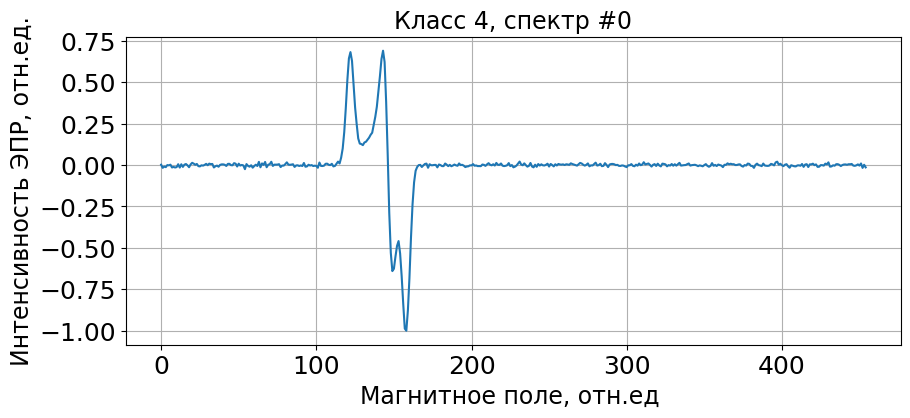

In [17]:
target_class = 4 # метка класса, можно выбрать любую
N = 1 # сколько графиков
count = 0 # счетчик
intensity_columns = [col for col in x_train.columns if col.startswith('intensity_')]

for i in range(len(y_test)):
    if y_test[i] == target_class:
        intensity = x_train.iloc[i][intensity_columns].values.astype(float)

        plt.figure(figsize=(10, 4))
        plt.plot(range(len(intensity)), intensity)
        plt.title(f"Класс {target_class}, спектр #{count}",fontsize=17)
        plt.xlabel("Магнитное поле, отн.ед ",fontsize=17)
        plt.ylabel("Интенсивность ЭПР, отн.ед.",fontsize=17)
        plt.xticks(fontsize=18)
        plt.yticks(fontsize=18)

        plt.grid(True)
        plt.show()

        count += 1
        if count >= N:
            break

# Модели классического машинного обучения

В данном разделе предствлен код для обучения и вывод метрик через classification_report для следующих моделей классического машинного обучения: SVM, RandomForest, LGBM, CatBoost, XGBoost

## LBGM

In [18]:
model_LGBM = lightgbm.LGBMClassifier(n_estimators=2000, verbose=-1)
model_LGBM.fit(x_train, y_train, sample_weight=weight_for_every_sample)
y_test_pred = model_LGBM.predict(x_test)
y_train_pred = model_LGBM.predict(x_train)

report=classification_report(y_test, y_test_pred)

In [19]:
report=classification_report(y_test, y_test_pred)
print(f"LGBM :\n {report}")

# Точность (accuracy)
acc = accuracy_score(y_test, y_test_pred)
print(f"Final Accuracy: {acc:.4f}")

# F1-метрика
f1 = f1_score(y_test, y_test_pred, average='macro')
print(f"Final F1 Score (macro): {f1:.4f}")

LGBM :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        15
           2       1.00      0.73      0.85        15
           3       1.00      0.60      0.75        15
           4       1.00      1.00      1.00        15
           5       0.64      0.93      0.76        15
           6       0.83      1.00      0.91        15

    accuracy                           0.90       105
   macro avg       0.92      0.90      0.89       105
weighted avg       0.92      0.90      0.89       105

Final Accuracy: 0.8952
Final F1 Score (macro): 0.8946


### Confusion matrix

Выведем и проанализируем матрицу ошибок для предсказаний модели LGBM

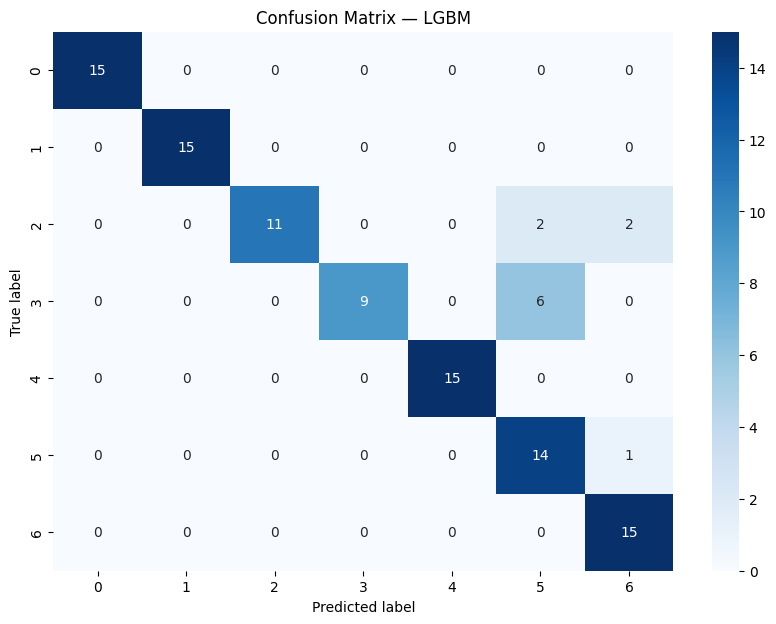

In [20]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — LGBM")
plt.show()



Определим степень влияния каждого из признаков на предсказания модели

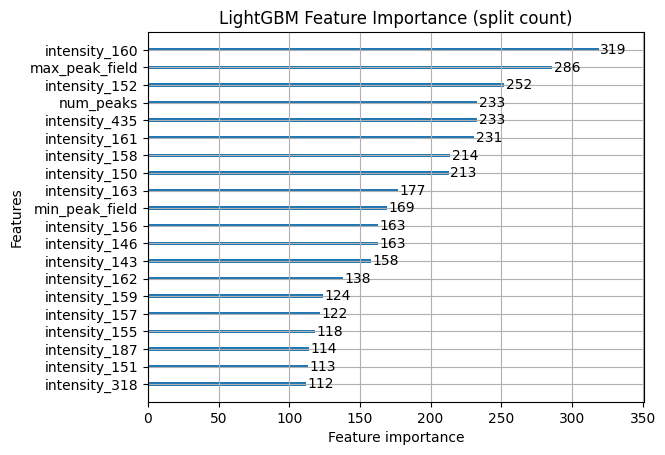

In [21]:
plot_importance(model_LGBM, max_num_features=20, importance_type='split')
plt.title("LightGBM Feature Importance (split count)")
plt.show()



## CatBoost и XGBoost

In [22]:
# Обучение CatBoost
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    verbose=0,  # отключает вывод
    random_state=42
)
cat_model.fit(x_train, y_train)
cat_preds = cat_model.predict(x_test)
print("CatBoost Report:\n", classification_report(y_test, cat_preds))


CatBoost Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94        15
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        15
           3       1.00      0.87      0.93        15
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00        15
           6       1.00      1.00      1.00        15

    accuracy                           0.98       105
   macro avg       0.98      0.98      0.98       105
weighted avg       0.98      0.98      0.98       105



In [23]:
# Обучение XGBoost
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(x_train, y_train)
xgb_preds = xgb_model.predict(x_test)

print("XGBoost Report:\n", classification_report(y_test, xgb_preds))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:16:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Report:
               precision    recall  f1-score   support

           0       0.79      1.00      0.88        15
           1       1.00      1.00      1.00        15
           2       1.00      0.73      0.85        15
           3       1.00      0.87      0.93        15
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00        15
           6       0.88      1.00      0.94        15

    accuracy                           0.94       105
   macro avg       0.95      0.94      0.94       105
weighted avg       0.95      0.94      0.94       105



Важность признаков и матрица ошибок для моделей CatBoost и XGBoost:

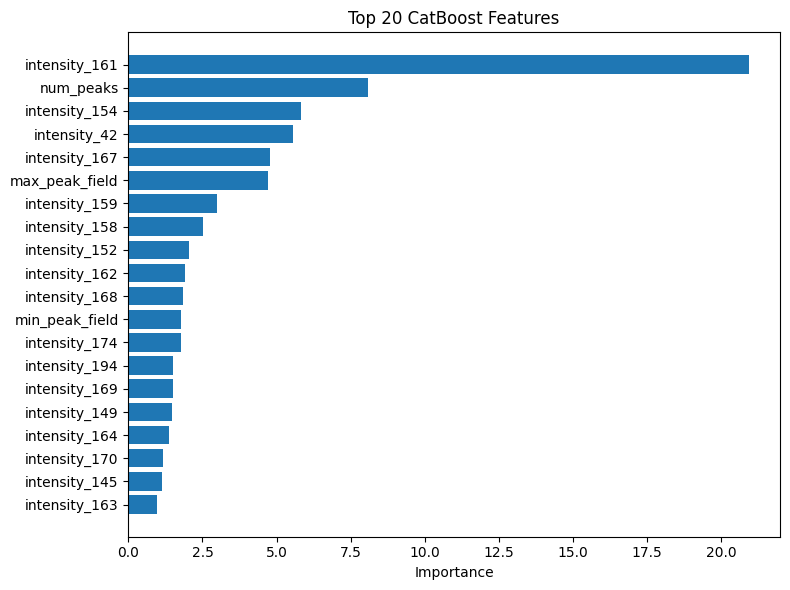

In [24]:
import matplotlib.pyplot as plt
imp = cat_model.get_feature_importance()
names = cat_model.feature_names_

df = pd.DataFrame({
    "feature": names,
    "importance": imp
}).sort_values("importance", ascending=False)


TOP_N = 20

plt.figure(figsize=(8, 6))
plt.barh(
    df.head(TOP_N)["feature"][::-1],
    df.head(TOP_N)["importance"][::-1]
)
plt.xlabel("Importance")
plt.title(f"Top {TOP_N} CatBoost Features")
plt.tight_layout()
plt.show()

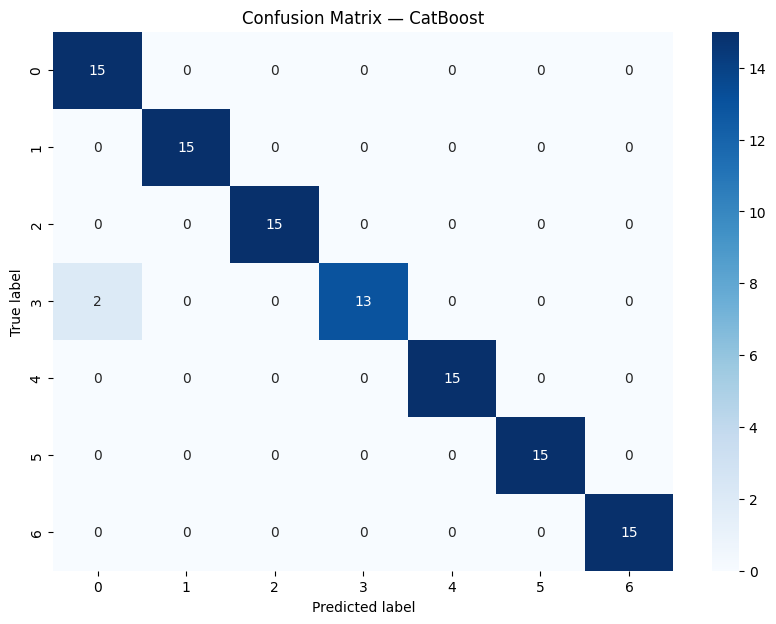

In [25]:
cm = confusion_matrix(y_test, cat_preds)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — CatBoost")
plt.show()

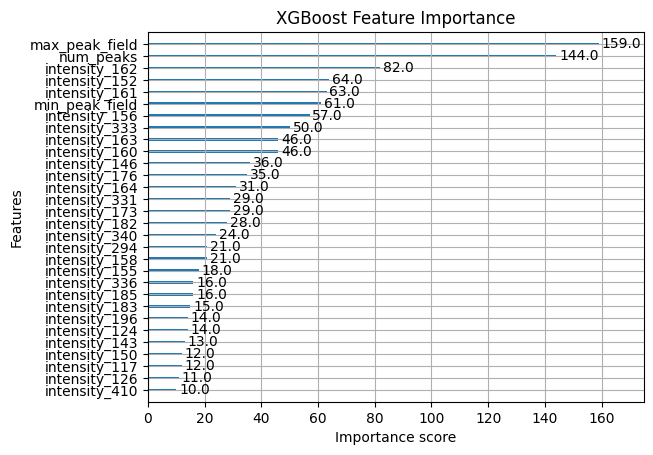

In [26]:
plot_importance_xgb(xgb_model, importance_type='weight', max_num_features=30)
plt.title("XGBoost Feature Importance")
plt.show()


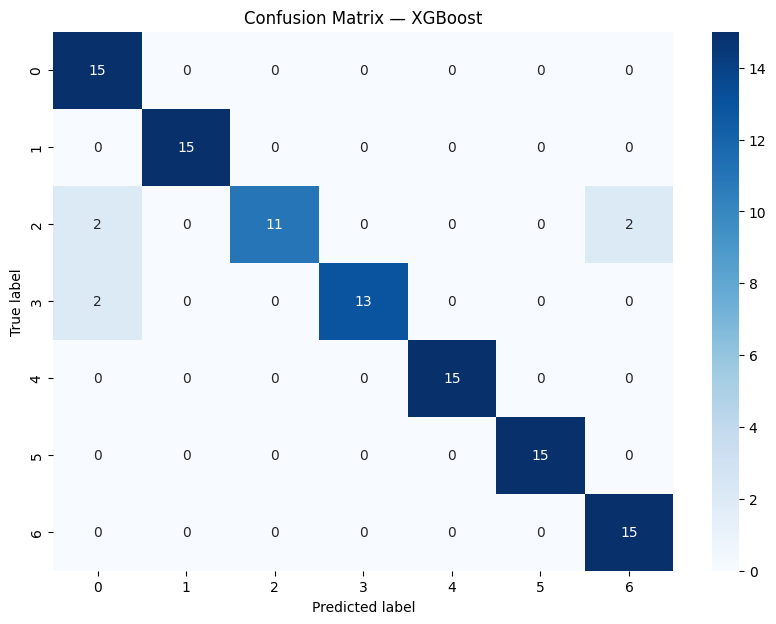

In [27]:
cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — XGBoost")
plt.show()

## SVM

In [28]:
# модель SVM с линейным ядром
model =LinearSVC(C=1, dual=False, max_iter=5000)

# Обучаем с весами weight_for_every_sample
model.fit(x_train, y_train, sample_weight=weight_for_every_sample)

y_test_pred = model.predict(x_test)

report=classification_report(y_test, y_test_pred)
print(f"SVM с линейным ядром:\n {report}")

SVM с линейным ядром:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94        15
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        15
           3       1.00      0.87      0.93        15
           4       1.00      1.00      1.00        15
           5       1.00      0.93      0.97        15
           6       0.94      1.00      0.97        15

    accuracy                           0.97       105
   macro avg       0.97      0.97      0.97       105
weighted avg       0.97      0.97      0.97       105



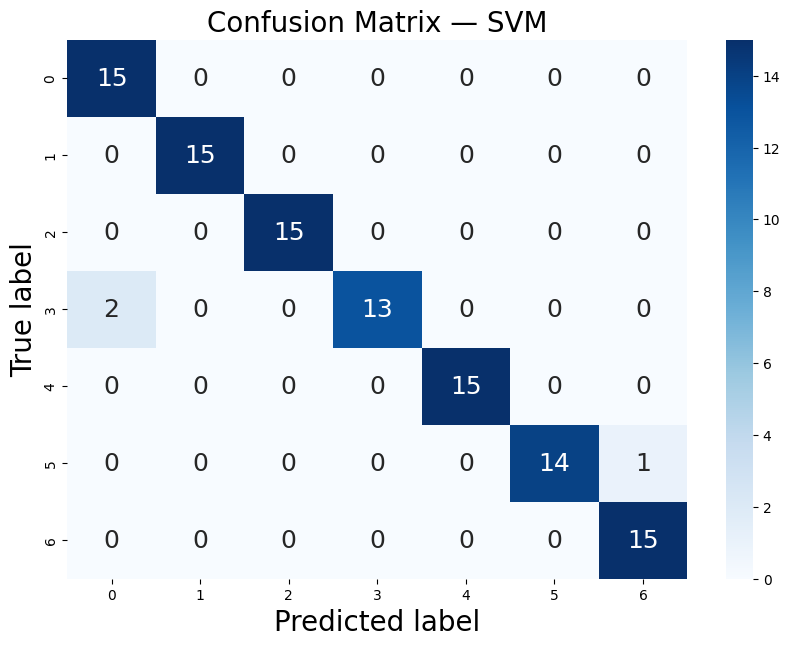

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",annot_kws={"size": 18})
plt.xlabel("Predicted label", fontsize=20)
plt.ylabel("True label",fontsize=20)
plt.title("Confusion Matrix — SVM",fontsize=20)
plt.show()


In [30]:
#модель SVM с полиномиальным ядром
model_svc_poly = SVC(kernel='poly',degree=3, C=1.0, coef0=1, gamma='scale', probability=False)

model_svc_poly.fit(x_train, y_train)

y_test_pred = model_svc_poly.predict(x_test)

report = classification_report(y_test, y_test_pred)
print(f"SVM с poly ядром:\n {report}")

SVM с poly ядром:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.00      0.00      0.00        15
           2       0.18      0.87      0.30        15
           3       0.00      0.00      0.00        15
           4       0.00      0.00      0.00        15
           5       0.57      0.27      0.36        15
           6       0.57      0.80      0.67        15

    accuracy                           0.28       105
   macro avg       0.19      0.28      0.19       105
weighted avg       0.19      0.28      0.19       105



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [31]:
#модель SVM с rbf ядром
model_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

model_rbf.fit(x_train, y_train)

y_test_pred = model_rbf.predict(x_test)

report = classification_report(y_test, y_test_pred)
print(f"SVM с poly ядром:\n {report}")

SVM с poly ядром:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.00      0.00      0.00        15
           2       0.14      1.00      0.25        15
           3       0.00      0.00      0.00        15
           4       0.00      0.00      0.00        15
           5       0.00      0.00      0.00        15
           6       0.00      0.00      0.00        15

    accuracy                           0.14       105
   macro avg       0.02      0.14      0.04       105
weighted avg       0.02      0.14      0.04       105



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## RandomForest

In [32]:
model_rf = RandomForestClassifier(n_estimators=1000)

model_rf.fit(x_train, y_train)

y_test_pred = model_rf.predict(x_test)

report=classification_report(y_test, y_test_pred)
print(f"Random forest:\n {report}")

Random forest:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90        15
           1       1.00      1.00      1.00        15
           2       1.00      0.73      0.85        15
           3       0.76      0.87      0.81        15
           4       0.94      1.00      0.97        15
           5       1.00      1.00      1.00        15
           6       1.00      1.00      1.00        15

    accuracy                           0.93       105
   macro avg       0.94      0.93      0.93       105
weighted avg       0.94      0.93      0.93       105



# Нейросетевые модели

## Модель ResNet18, модифицированная для работы с одномерными данными

Модель была модифицирована для работы с одномерными данными, также в ней было изменено число каналов в блоках и nn.AdaptiveAvgPool

In [33]:
class BasicBlock(nn.Module):
    expansion: int = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(
            out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity  # Сложение с остаточным соединением (skip connection)
        out = self.relu(out)

        return out


class ResNet_1D(nn.Module):
    def __init__(self, num_classes: int = 1000):
        super().__init__()
        self.in_channels = 128
        self.conv1 = nn.Conv1d(
            1, self.in_channels, kernel_size=3, stride=2, padding=3, bias=False
        )
        self.bn1 = nn.BatchNorm1d(128)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(128, 2)
        self.layer2 = self._make_layer(256, 2, stride=2)
        self.layer3 = self._make_layer(512, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool1d(8)
        self.dropout = nn.Dropout(p=0.6)
        self.fc = nn.Linear(512*8 , num_classes)

    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None

        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv1d(
                    self.in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm1d(out_channels),
            )

        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)

        return x

## Код для обучения

In [34]:
class ResNet1D_Lit(pl.LightningModule):
    def __init__(self, num_classes=7, lr=1e-4):
        super().__init__()
        self.model = ResNet_1D(num_classes=num_classes)  # ResNet-18 1D
        self.criterion = nn.CrossEntropyLoss()
        # metrics
        self.metrics = MetricCollection(
            [
                MulticlassAccuracy(
                    num_classes=7,
                ),
                MulticlassF1Score(
                    num_classes=7,
                ),
            ]
        )
        self.train_metrics = self.metrics.clone(postfix="/train")
        self.val_metrics = self.metrics.clone(postfix="/val")
        self.test_metrics = self.metrics.clone(postfix="/test")
        self.lr = lr

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        if y.ndimension() > 1:
            y = y.argmax(dim=1)
        out = self.model(x)
        loss = self.criterion(out, y)
        #probs = torch.sigmoid(out)
        #preds = (probs > 0.5).int()
        self.train_metrics.update(out.softmax(-1),y)
        self.log("loss/train", loss, prog_bar=True,on_epoch=True)


        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        if y.ndimension() > 1:
            y = y.argmax(dim=1)
        out = self.model(x)
        loss = self.criterion(out, y)
        #probs = torch.sigmoid(out)
        #preds = (probs > 0.5).int()
        self.val_metrics.update(out.softmax(-1), y)
        self.log("loss/val", loss, prog_bar=True, on_epoch=True)
        return loss

    def on_train_epoch_end(self):
        # Логируем метрики тренировки
        self.log_dict(self.train_metrics.compute(),on_epoch=True, prog_bar=True)
        self.train_metrics.reset()

    def on_validation_epoch_end(self):
        # Логируем метрики валидации
        self.log_dict(self.val_metrics.compute(),on_epoch=True, prog_bar=True)
        self.val_metrics.reset()

    def test_step(self, batch, batch_idx):
        x, y = batch
        if y.ndimension() > 1:
            y = y.argmax(dim=1)
        out = self.model(x)
        loss = self.criterion(out, y)
        #probs = torch.sigmoid(out)
        #preds = (probs > 0.5).int()
        self.test_metrics.update(out.softmax(-1),y)
        self.log("loss/test", loss, prog_bar=True, on_epoch=True)
        return loss

    def on_test_epoch_end(self):
        self.log_dict(self.test_metrics.compute(),on_epoch=True, prog_bar=True)
        self.test_metrics.reset()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.model.parameters(), lr=self.lr, weight_decay=1e-5
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5,patience=5)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch",  # or 'step'
                "monitor": "loss/val",  # only for self.log
            },
        }

In [35]:
model_1D = ResNet1D_Lit(num_classes=7, lr=1e-6)
exp_name = "model_resnet18_modif"

xb, yb = next(iter(train_loader))
out = model_1D(xb)
print("out shape:", out.shape)

# логируем
logger = TensorBoardLogger("logs", name=exp_name)


checkpoint_callback = ModelCheckpoint(
    monitor="MulticlassAccuracy/val", mode="max", filename="best"
)

early_stop = EarlyStopping(
    monitor="loss/val",
    mode="min",
    patience=20
)

# Создаем Trainer
trainer = Trainer(
    max_epochs=300,
    logger=logger,
    callbacks=[checkpoint_callback, early_stop],
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
)

trainer.fit(model_1D, train_loader, test_loader)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


out shape: torch.Size([64, 7])


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ ResNet_1D        │  7.3 M │ train │     0 │
│ 1 │ criterion     │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ metrics       │ MetricCollection │      0 │ train │     0 │
│ 3 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 5 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 7.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.3 M                                                                                                
Total estimated model params size (MB): 29                                                                         
Modules in train mode: 82                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches 
(15) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if
you want to see logs for the training epoch.

Модель ResNet18 при корректном подборе структурных параметров и
гиперпараметров достигла высокого качества классификации : Accuracy = 98%, F1 = 98%. Загрузить лучшую обученную модель и проверить ее качество на тестовых данных возможно в последних двух разделах данного блокнота

## Код для конвертации 2d cnn моделей из библиотеки timm для работы с одномерными данными (без изменения параметров)

Другие модели были импортированы из timm, модифицированы для работы с одномерными данными без изменения структуры

In [36]:
! wget https://fls.avasiliev.xyz/src/2d1d_utils/convert2d1d.py
from convert2d1d import create_1d_model

--2026-03-19 12:20:14--  https://fls.avasiliev.xyz/src/2d1d_utils/convert2d1d.py
Resolving fls.avasiliev.xyz (fls.avasiliev.xyz)... 79.174.84.131
Connecting to fls.avasiliev.xyz (fls.avasiliev.xyz)|79.174.84.131|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10359 (10K) [application/octet-stream]
Saving to: ‘convert2d1d.py’

convert2d1d.py      100%[===================>]  10.12K  --.-KB/s    in 0s      

2026-03-19 12:20:15 (286 MB/s) - ‘convert2d1d.py’ saved [10359/10359]



In [37]:
#вместо model_name можно подставить любую модель:resnet18, resnet34, efficientnet_b0, efficientnet_b3, mobilenetv2_100
timm_model_1d = create_1d_model(model_name='efficientnet_b0', num_classes=7, in_chans=1)

## Код для обучения импортированной модели из timm

In [38]:
class NeuralNetwork1D(pl.LightningModule):
    def __init__(self, num_classes=7, lr=1e-4):
        super().__init__()
        self.model = timm_model_1d
        self.criterion = nn.CrossEntropyLoss()
        # metrics
        self.metrics = MetricCollection(
            [
                MulticlassAccuracy(
                    num_classes=7,
                ),
                MulticlassF1Score(
                    num_classes=7,
                ),
            ]
        )
        self.train_metrics = self.metrics.clone(postfix="/train")
        self.val_metrics = self.metrics.clone(postfix="/val")
        self.test_metrics = self.metrics.clone(postfix="/test")
        self.lr = lr

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        if y.ndimension() > 1:
            y = y.argmax(dim=1)
        out = self.model(x)
        loss = self.criterion(out, y)
        #probs = torch.sigmoid(out)
        #preds = (probs > 0.5).int()
        self.train_metrics.update(out.softmax(-1),y)
        self.log("loss/train", loss, prog_bar=True,on_epoch=True)


        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        if y.ndimension() > 1:
            y = y.argmax(dim=1)
        out = self.model(x)
        loss = self.criterion(out, y)
        #probs = torch.sigmoid(out)
        #preds = (probs > 0.5).int()
        self.val_metrics.update(out.softmax(-1), y)
        self.log("loss/val", loss, prog_bar=True, on_epoch=True)
        return loss

    def on_train_epoch_end(self):
        # Логируем метрики тренировки
        self.log_dict(self.train_metrics.compute(),on_epoch=True, prog_bar=True)
        self.train_metrics.reset()

    def on_validation_epoch_end(self):
        # Логируем метрики валидации
        self.log_dict(self.val_metrics.compute(),on_epoch=True, prog_bar=True)
        self.val_metrics.reset()

    def test_step(self, batch, batch_idx):
        x, y = batch
        if y.ndimension() > 1:
            y = y.argmax(dim=1)
        out = self.model(x)
        loss = self.criterion(out, y)
        #probs = torch.sigmoid(out)
        #preds = (probs > 0.5).int()
        self.test_metrics.update(out.softmax(-1),y)
        self.log("loss/test", loss, prog_bar=True, on_epoch=True)
        return loss

    def on_test_epoch_end(self):
        self.log_dict(self.test_metrics.compute(),on_epoch=True, prog_bar=True)
        self.test_metrics.reset()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.model.parameters(), lr=self.lr, weight_decay=1e-3
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5,patience=8)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch",  # or 'step'
                "monitor": "loss/val",  # only for self.log
            },
        }

In [39]:
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping,ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger

# Создаем модель
model = NeuralNetwork1D(num_classes=7, lr=1e-4)
exp_name = "eff_b0_model1"

# логируем
logger = TensorBoardLogger("logs", name=exp_name)

checkpoint_callback = ModelCheckpoint(
    monitor="MulticlassAccuracy/val", mode="max", filename="best"
)

early_stop = EarlyStopping(
    monitor="loss/val",
    mode="min",
    patience=20
)

# Создаем Trainer
trainer = Trainer(
    max_epochs=300,
    logger=logger,
    callbacks=[checkpoint_callback, early_stop],
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
)

#Обучаем модель
trainer.fit(model, train_loader, val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ EfficientNet     │  3.9 M │ train │     0 │
│ 1 │ criterion     │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ metrics       │ MetricCollection │      0 │ train │     0 │
│ 3 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 5 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 3.9 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.9 M                                                                                                
Total estimated model params size (MB): 15                                                                         
Modules in train mode: 350                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

## Загрузка лучшей обученной модели для одномерных данных

Лучшие результаты показала модель ResNet18 при корректном подборе структурных параметров и
гиперпараметров: Accuracy = 98%, F1 = 98%.

In [40]:
file_id = "1K-SEF_JWvSvw0otsmgNyWVoZew2eQ3G1"
gdown.download(id=file_id, output="best_resnet18.ckpt", quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=1K-SEF_JWvSvw0otsmgNyWVoZew2eQ3G1
From (redirected): https://drive.google.com/uc?id=1K-SEF_JWvSvw0otsmgNyWVoZew2eQ3G1&confirm=t&uuid=ee7590ae-8048-4f49-baf8-48a61cc2436e
To: /content/best_resnet18.ckpt
100%|██████████| 87.2M/87.2M [00:01<00:00, 86.4MB/s]


'best_resnet18.ckpt'

In [41]:
# Загрузка модели из чекпоинта
model = ResNet1D_Lit.load_from_checkpoint(
    "best_resnet18.ckpt",
    weights_only=False
)

## Проверка качества лучшей обученной модели на тестовых данных

In [42]:
def evaluate_model(model, dataloader, device="cpu"):
    model.eval()
    model.to(device)
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            if labels.ndim > 1:
                labels = torch.argmax(labels, dim=1)
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Оценка модели
all_labels, all_preds = evaluate_model(model, test_loader, device=device)

# Вывод отчета
print("Classification Report:")
print(classification_report(all_labels, all_preds))

# Точность (accuracy)
acc = accuracy_score(all_labels, all_preds)
print(f"Final Accuracy: {acc:.4f}")

# F1-метрика (в среднем по классам)
f1 = f1_score(all_labels, all_preds, average='macro')  # или 'weighted', 'micro'
print(f"Final F1 Score (macro): {f1:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        15
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        15
           3       1.00      0.87      0.93        15
           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00        15
           6       1.00      1.00      1.00        15

    accuracy                           0.98       105
   macro avg       0.98      0.98      0.98       105
weighted avg       0.98      0.98      0.98       105

Final Accuracy: 0.9810
Final F1 Score (macro): 0.9809
